# Constant-coefficient linear PDEs: operator algebra

The equation $u_t-u_x=e^{x+t}$ illustrates the operator-symbol subsystem, homogeneous-plus-particular decomposition, and exact residual checking.

**Tutorial contract.** This notebook derives the mathematics, asks PDESolve how it recognizes/plans the problem, executes the solver, independently checks the returned mathematics where appropriate, visualizes the solution or its structure, and ends with runnable variations plus exercises.

In [1]:
from pathlib import Path
import sys

# Make a source checkout importable without requiring an editable install.
root = Path.cwd().resolve()
for candidate in [root, *root.parents]:
    if (candidate / "pdesolve").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the pdesolve source tree")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pdesolve as pds
from IPython.display import display

sp.init_printing()
print("PDESolve source:", ROOT)
print("SymPy:", sp.__version__)

PDESolve source: /mnt/data/pdesolve_doc22SymPy: 1.14.0

In [2]:
def show_plan(problem, n=6):
    """Display recognizer output and the highest-ranked canonical plan steps."""
    rec = pds.recognize_canonical_problem(problem)
    plan = pds.plan_canonical_problem(problem)
    print("Recognition:", rec)
    print("Top plan steps:")
    for step in plan.steps[:n]:
        print(f"  {step.method:42s} score={step.score}")
    return rec, plan


def rhs_of(solution):
    """Extract the RHS of an Eq result, or return an expression unchanged."""
    return solution.rhs if isinstance(solution, sp.Equality) else solution


def residual(eq, dependent, candidate):
    """Classical residual after replacing the dependent function by candidate."""
    expr = eq.lhs - eq.rhs if isinstance(eq, sp.Equality) else eq
    return sp.simplify(expr.subs(dependent, candidate).doit())

## 1. Operator DerivationLet $L=D_t-D_x$. Since $L(e^{x+t})=0$, the naive exponential ansatz resonates with the homogeneous operator. Multiplying by $t$ gives a particular solution$$u_p=t e^{x+t},$$and direct differentiation shows $L u_p=e^{x+t}$. The homogeneous family is an arbitrary function of $x+t$.

In [3]:
x,t=sp.symbols("x t", real=True)
u=sp.Function("u")
eq=sp.Eq(sp.diff(u(x,t),t)-sp.diff(u(x,t),x),sp.exp(x+t))
problem=pds.build_pde_problem(eq,u(x,t),(x,t))
recognition, plan=show_plan(problem)

Recognition: (PDERecognitionRecord(family='first_order_linear', recognized=True, solver_hint='first_order', tags=('characteristics',), metadata={'constant_coefficient': False}),)Top plan steps:  constant_coefficient_inverse_operator      score=92  first_order                                score=76  symmetry_reduction                         score=52  post_reduction_auto                        score=48

In [4]:
from pdesolve.classical import pdesolve_constant_coefficient
result=pdesolve_constant_coefficient(eq,u(x,t),(x,t))
print(type(result).__name__, result.method)
display(result.solution)
print(result.metadata["method_family_report"])

PDEGeneralSolutionResult constant_coefficient_homogeneous_plus_particular

{'selected_method': 'constant_coefficient_homogeneous_plus_particular', 'method_family': 'homogeneous', 'particular_method': 'constant_coefficient_polynomial_exponential', 'particular_method_family': 'exponential', 'homogeneous_method': 'constant_coefficient_homogeneous_family', 'homogeneous_method_family': 'homogeneous', 'fit_strategy': None}

In [5]:
particular=t*sp.exp(x+t)
print("Particular residual:", residual(eq,u(x,t),particular))
assert residual(eq,u(x,t),particular)==0

Particular residual: 0

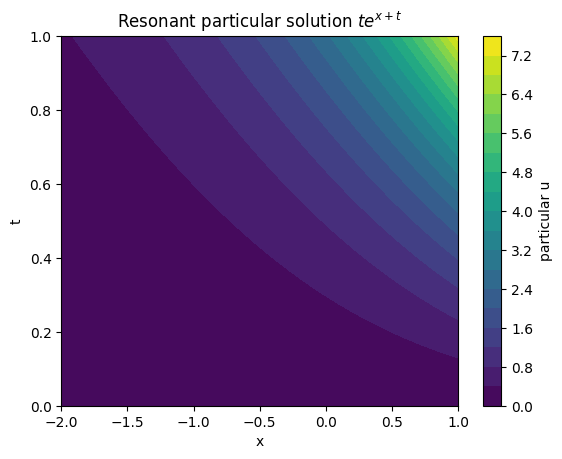

In [6]:
xx=np.linspace(-2,1,180); tt=np.linspace(0,1,120); X,T=np.meshgrid(xx,tt); Z=T*np.exp(X+T)
fig,ax=plt.subplots(); cs=ax.contourf(X,T,Z,levels=20); fig.colorbar(cs,ax=ax,label="particular u")
ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title("Resonant particular solution $t e^{x+t}$"); plt.show()

## 3. Variation and exercisesChange the forcing to a nonresonant exponential. Then: (1) predict the particular ansatz before running the solver; (2) inspect the method-family report; (3) add conditions and see whether the homogeneous arbitrary function can be fitted.

In [7]:
eq2=sp.Eq(sp.diff(u(x,t),t)-sp.diff(u(x,t),x),sp.exp(2*x+t))
r2=pdesolve_constant_coefficient(eq2,u(x,t),(x,t))
print(r2.method); display(r2.solution)

constant_coefficient_homogeneous_plus_particular